In [1]:
#----------------------------------------
# IMPORTS
#----------------------------------------
import numpy as np
import pathlib, os
import pyklip.klip as klip
from my_klip import LBT
import pyklip.parallelized as parallelized
from astropy.io import fits
import matplotlib.pyplot as plt
print("imports loaded")

imports loaded


In [2]:
obj = 'procyon'

reduced_data = np.load(obj+"_NOMIC_reduced.npz", allow_pickle=True)
array_shape = reduced_data["arr_3"]
file_size = reduced_data["arr_4"]
reffit = reduced_data["arr_7"]

binned_data = np.load(obj+"_NOMIC_binned2_evaluated.npz", allow_pickle=True)
binned_files = binned_data["arr_0"]
binned_chops = binned_data["arr_1"]
binned_angles = binned_data["arr_2"]

origin = [array_shape[0]/2 - 0.5, array_shape[0]/2 - 0.5]
root_dir = os.path.dirname(os.path.dirname(binned_files[0]))
print(root_dir)
a_klipped_dir=os.path.join(root_dir,'fhalf_klipped')
b_klipped_dir=os.path.join(root_dir,'shalf_klipped')

if not os.path.exists(a_klipped_dir):
    os.makedirs(a_klipped_dir)
if not os.path.exists(b_klipped_dir):
    os.makedirs(b_klipped_dir)

print("file loaded")
print(len(binned_files))

C:\Users\mmc\Music\Procyon
file loaded
249


In [3]:

chopa_dataset = LBT(binned_files[:100], PAs=binned_angles[:100],\
                    framew=array_shape[0], frameh=array_shape[1], origin=origin)
chopb_dataset = LBT(binned_files[101:], PAs=binned_angles[101:],\
                    framew=array_shape[0], frameh=array_shape[1], origin=origin)

parallelized.klip_dataset(chopa_dataset, outputdir=a_klipped_dir, 
                          annuli=1, subsections=1, movement=2, numbasis=[10, 20,50],
                          calibrate_flux=False, mode="ADI")
parallelized.klip_dataset(chopb_dataset, outputdir=b_klipped_dir, 
                          annuli=1, subsections=1, movement=2, numbasis=[10, 20,50],
                          calibrate_flux=False, mode="ADI")

Begin align and scale images for each wavelength
Wavelength 1.0 with index 0 has finished align and scale. Queuing for KLIP
Total number of tasks for KLIP processing is 1


  0%|          | 0/1 [00:00<?, ?it/s]

Closing threadpool
Derotating Images...
Writing Images to directory C:\Users\mmc\Music\Procyon\fhalf_klipped
wavelength collapsing reduced data of shape (b, N, wv, y, x):(3, 100, 1, 696, 668)
Begin align and scale images for each wavelength
Wavelength 1.0 with index 0 has finished align and scale. Queuing for KLIP
Total number of tasks for KLIP processing is 1


  0%|          | 0/1 [00:00<?, ?it/s]

Closing threadpool
Derotating Images...
Writing Images to directory C:\Users\mmc\Music\Procyon\shalf_klipped
wavelength collapsing reduced data of shape (b, N, wv, y, x):(3, 148, 1, 696, 668)


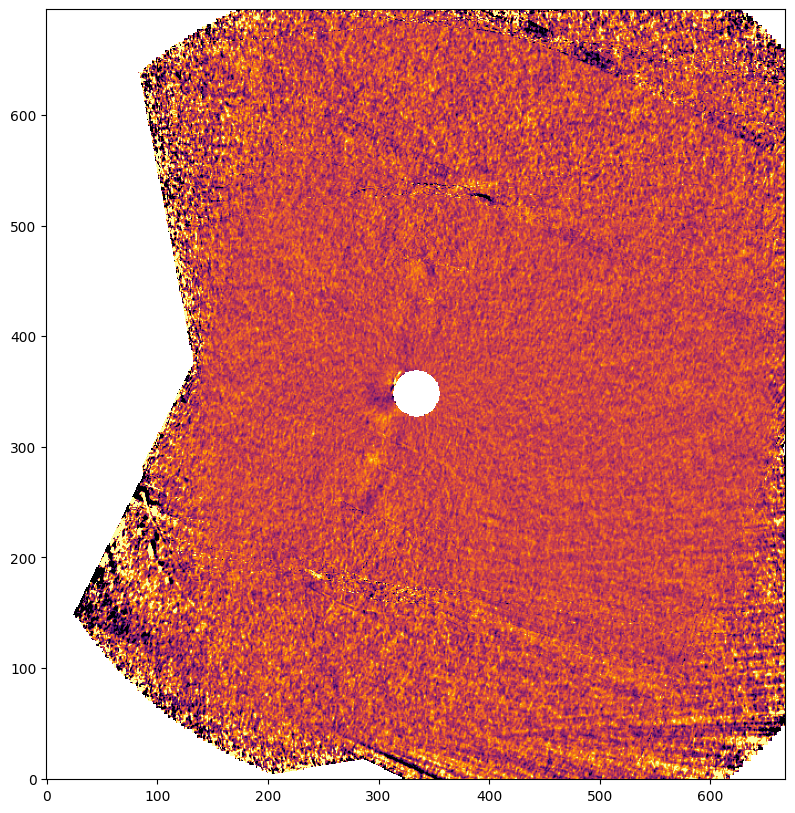

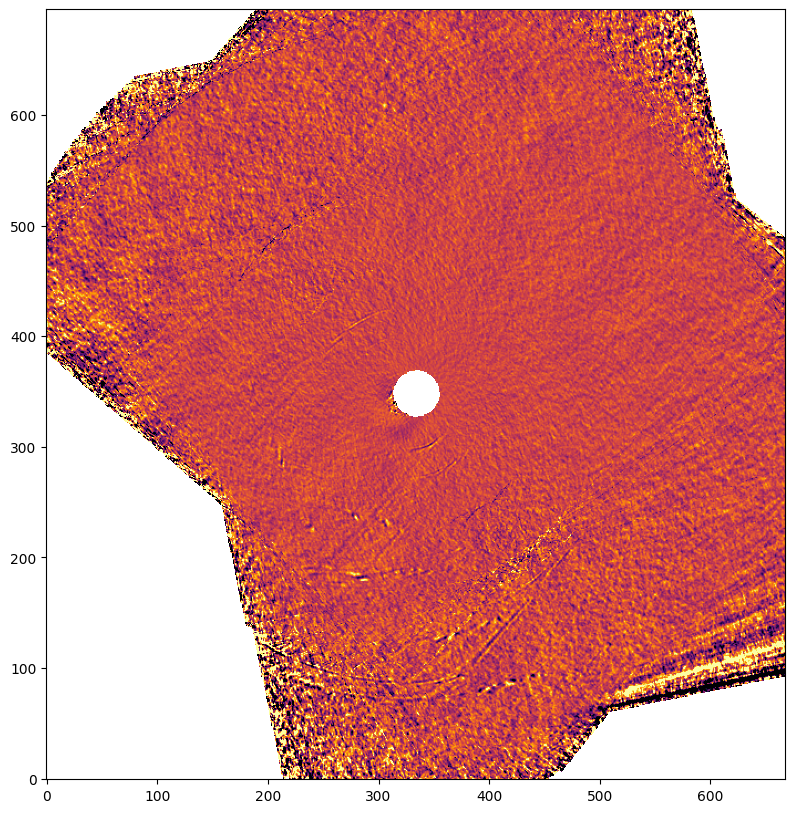

In [4]:
a_klipped = fits.open(os.path.join(a_klipped_dir, "-KLmodes-all.fits"))

plt.figure(figsize=(10,10))
plt.imshow(a_klipped[0].data[1], cmap="inferno", vmin=-0.5, vmax=0.4, origin="lower")
plt.show()

b_klipped = fits.open(os.path.join(b_klipped_dir, "-KLmodes-all.fits"))

plt.figure(figsize=(10,10))
plt.imshow(b_klipped[0].data[1], cmap="inferno", vmin=-0.5, vmax=0.4, origin="lower")
plt.show()